In [25]:
import sys
!{sys.executable} -m pip install tensorflow


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 역전파
- pseudo code


- 순전파
```python
for 배치 in 전체데이터:
   x, y = 배치    # 입력


   z1 = x @ w1 + b1    # 첫번째 층 통과
   a1 = activation(z1)  # 첫번째 층 활성화 함수 적용


   z2 = a1 @ w2 + b2
   y_pred = activation(z2)  # 출력층 활성화 함수 통과


   loss = loss_fn(y, y_pred)  # 실제정답, 예측값의 차이를 계산
```


-역전파
'''python
for 배치 in 전체데이터:
    y_hat = 순전파(x)
    loss = 손실함수(y, y_hat) #오차계산
    gradients = 역전파(loss) # 역전파로 기울기를 계산
    W = W - learning_rate * gradients # 가중치를 업데이트
'''


## 기울기 소실

In [26]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 시그모이드 함수의 도함수
def sigmoid_deriv(z):
    s = sigmoid(z)
    return s * (1 - s)

z_vals = np.linspace(-5, 5, 1000)
max_deriv = sigmoid_deriv(z_vals).max()
print(max_deriv)

# 시그모이드 함수에서 기울기의 최댓값은 0.25
#  3층짜리 신경망에서 활성화 함수 시그모이드로 사용
#  1층 기울기 최대: 0.25
#  2층 기울기 최대: 0.25 * 0.25 = 0.0625
#  3층 기울기 최대: 0.25 * 0.25 * 0.25 = 0.015625


0.24999843437684274


In [27]:
0.25 * 0.25 * 0.25

0.015625

In [28]:
# 층이 더해질 수록 기울기가 소실된다.
# 역전파에서 기울기를 업데이트 하려고 할 때, 기울기가 소실되면 너무 작아서 업데이트가 거의 이루어지지 않는다.
# 기울기 소실을 막기 위해 ReLu가 등장한다.


In [29]:
# ReLU
def relu(z):
    return max(0, z)

test_vals = [-5, -3, 0, 3, 5]
for z in test_vals:
    print(f"{z}: {relu(z)}")
    
# 0 이상으로는 기울기가 소멸 되지 않는다.
#  0 이하면 기울기 0,이상이면 1
# 음수의 경우 계산 X
# LeakyReLu, EUT


-5: 0
-3: 0
0: 0
3: 3
5: 5


패션 MNIST

In [30]:
import tensorflow as tf  # tensorflow 먼저 (keras가 tf에 의존)
import keras             # tf에 포함된 keras 불러오기

# 버전 확인 (처음 셋업할 때 습관적으로 달아두면 좋음)
print("TF  :", tf.__version__)
print("Keras:", keras.__version__)

TF  : 2.21.0
Keras: 3.14.1


In [31]:
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [32]:
import sys
!{sys.executable} -m pip install matplotlib

  Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp311-cp311-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.3-cp311-cp311-win_amd64.whl (225 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.63.0-cp311-cp311-win_amd64.whl (2.4 MB)
Using cached kiwisolver-1.5.0-cp311-cp311-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp311-cp311-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


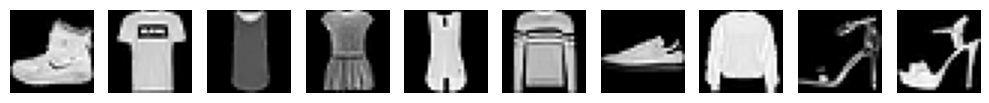

In [33]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10, 10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')  # [i]: i번째 이미지, cmap='gray': 흑백
    axs[i].axis('off')  # 축 숨기기
plt.tight_layout()
plt.show()

In [34]:
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

In [35]:
train_scaled = train_input /255.0
train_scaled = train_scaled.reshape(-1,28*28)
train_scaled.shape

(60000, 784)

In [36]:
keras.layers.Input(shape=(784,))

<KerasTensor shape=(None, 784), dtype=float32, sparse=False, ragged=False, name=keras_tensor_5>

In [37]:
input_layer = keras.layers.Input(shape=(784,))
output_layer = keras.layers.Dense(units=10, activation='softmax')
model = keras.Sequential([input_layer, output_layer])

In [38]:
model.compile(
    optimizer='adam',                           # 공부법: Adam
    loss='sparse_categorical_crossentropy',     # 채점 기준: 정수 정답용
    metrics=['accuracy']                        # 보고 싶은 점수: 정확도
)

In [39]:
model.fit(
    train_scaled, train_target,  # 입력 데이터, 정답 레이블
    epochs=5                     # 전체 데이터 5회 반복
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 804us/step - accuracy: 0.8014 - loss: 0.5955
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 796us/step - accuracy: 0.8425 - loss: 0.4609
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step - accuracy: 0.8502 - loss: 0.4352
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.8533 - loss: 0.4229
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 792us/step - accuracy: 0.8576 - loss: 0.4139


In [40]:
# 단층 신경망
# -ANN : Artificial Neural Network
# 입력층 -> 출력층

# 심층 신경망
# DNN: Deep Neural Network
# 입력층 -> 은닉층 -> 출력층
# 은닉층이 2개 이상으로 깊게 쌓아올린 신경층
# 딥러닝 기술의 기반

In [41]:
# 데이터 가져오기
(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [42]:
from sklearn.model_selection import train_test_split


train_scaled = train_input / 255.0
train_scaled = train_scaled.reshape(-1, 28*28)


train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
train_scaled.shape, val_scaled.shape

NameError: name 'train_scaled' is not defined

In [ ]:
input_layer = keras.layers.Input(shape=(784,))
dense1 = keras.layers.Dense(100, activation='sigmoid') # 은닉층
dense2 = keras.layers.Dense(10, activation='softmax')

In [ ]:
# 방법 1: 미리 정의한 층 변수를 리스트에 담기
model = keras.Sequential([input_layer, dense1, dense2])  # dense1(은닉), dense2(출력) 추가

In [ ]:
#2번 
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(100, activation='sigmoid', name='hidden_layer'),
    keras.layers.Dense(10, activation='softmax', name='output_layer')
    ],
)

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 100)            │        78,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,510 (310.59 KB)

 Trainable params: 79,510 (310.59 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',                           # 공부법: Adam
    loss='sparse_categorical_crossentropy',     # 채점 기준: 정수 정답용
    metrics=['accuracy']                        # 보고 싶은 점수: 정확도
)

In [ ]:
# 학습: 문제집 5회독
model.fit(
    train_scaled, train_target,
    epochs=5,
    validation_data=(val_scaled, val_target)  # 매 epoch마다 모의고사
)

In [ ]:
# 평가: 검증 데이터로 최종 점수 확인
loss, accuracy = model.evaluate(val_scaled, val_target)
print(f'val_loss    : {loss:.4f}')
print(f'val_accuracy: {accuracy:.4f}')  # 목표: 0.8723 이상